In [1]:
%load_ext autoreload
%autoreload 2

In [61]:
import pandas as pd
import os
import json
import dotenv
import networkx as nx
from tqdm import tqdm
from matplotlib import pyplot as plt

dotenv.load_dotenv()

True

In [3]:
data_path = '/Users/ahmed/Desktop/msc-24/ECHR_v2/echr_processed'
files = os.listdir(data_path)

In [82]:
data_path = '/Users/ahmed/Desktop/msc-24/ECHR/echr-processed'
files = os.listdir(data_path)

t = []
for file in files:
    if 'json' in file:
        with open(os.path.join(data_path, file)) as f:
            data = json.load(f)
            if data['importance'] == '4':
                articles = data['article']
                if '41' in articles:
                    t.append(file)


In [83]:
t

['001-67085.json',
 '001-76694.json',
 '001-77986.json',
 '001-61501.json',
 '001-67986.json',
 '001-72638.json',
 '001-73183.json',
 '001-67713.json',
 '001-73245.json',
 '001-68409.json',
 '001-67206.json',
 '001-70193.json',
 '001-71805.json',
 '001-61106.json',
 '001-61556.json',
 '001-60717.json',
 '001-59883.json',
 '001-76339.json',
 '001-76293.json',
 '001-68632.json',
 '001-71940.json',
 '001-58457.json',
 '001-76155.json',
 '001-60982.json',
 '001-77251.json',
 '001-61540.json',
 '001-77494.json',
 '001-59483.json',
 '001-69465.json',
 '001-60994.json',
 '001-72100.json',
 '001-60428.json',
 '001-77247.json',
 '001-72291.json',
 '001-60756.json',
 '001-76728.json',
 '001-59987.json',
 '001-60613.json',
 '001-61901.json',
 '001-68673.json',
 '001-67586.json',
 '001-78223.json',
 '001-61452.json',
 '001-70243.json',
 '001-72854.json',
 '001-70869.json',
 '001-66817.json',
 '001-75692.json',
 '001-61281.json',
 '001-59712.json',
 '001-60886.json',
 '001-76952.json',
 '001-73253.

In [23]:
df1_path = '/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_1.csv'
df2_path = '/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_2.csv'
df3_path = '/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_3.csv'
df4_path = '/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_4.csv'

df1 = pd.read_csv(df1_path); df1['importance'] = 'kc'
df2 = pd.read_csv(df2_path); df2['importance'] = 'high'
df3 = pd.read_csv(df3_path); df3['importance'] = 'medium'
df4 = pd.read_csv(df4_path); df4['importance'] = 'low'


In [57]:
def collect_articles(df):
    file_names = list(df['file_path'].values)
    all_articles = []
    for file in tqdm(file_names):
        with open(f'{data_path}/{file}') as f:
            data = json.load(f)
            all_articles.append(data['article'])
    return all_articles

In [58]:
df1_articles = collect_articles(df1); df1['articles'] = df1_articles
df2_articles = collect_articles(df2); df2['articles'] = df2_articles
df3_articles = collect_articles(df3); df3['articles'] = df3_articles
df4_articles = collect_articles(df4); df4['articles'] = df4_articles

  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 125/125 [00:00<00:00, 1531.83it/s]


In [59]:
df = pd.concat([df1, df2, df3, df4], axis=0)

In [60]:
df.to_csv('cases_data.csv')

<Figure size 1400x800 with 0 Axes>

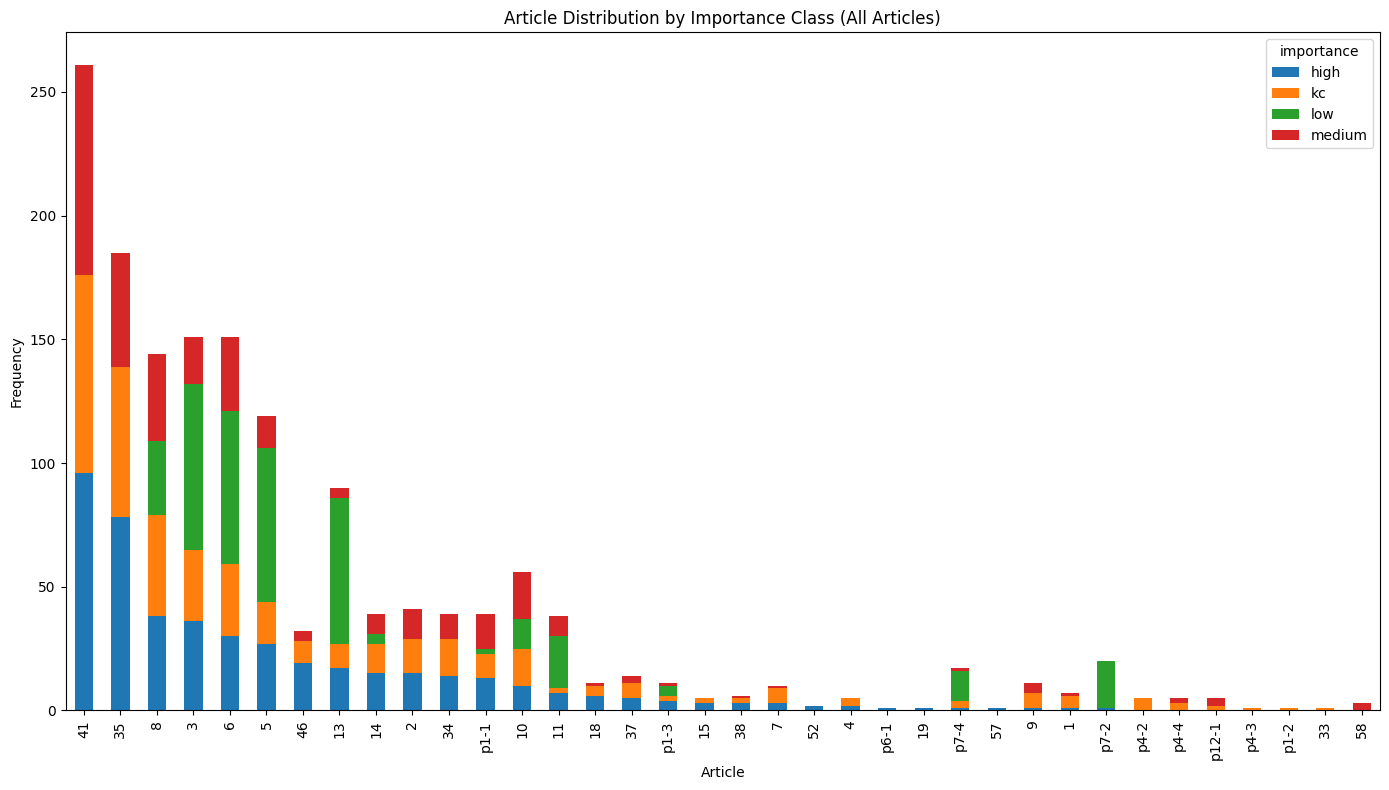

In [64]:
importance_article_counts = df.groupby('importance')['articles'].apply(
    lambda x: [article for sublist in x for article in sublist]
)

# Get the count of each article per importance class
importance_article_counts = importance_article_counts.apply(lambda x: pd.Series(x).value_counts()).fillna(0)

# Plot the distribution of all articles by importance class
plt.figure(figsize=(14, 8))
importance_article_counts.T.plot(kind='bar', stacked=True, figsize=(14, 8))

plt.title("Article Distribution by Importance Class (All Articles)")
plt.xlabel("Article")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [65]:
# Filter the dataset to find cases with Article 41 and importance 'low'
low_class_cases_with_article_41 = df[(df['importance'] == 'low') & 
                                               df['articles'].apply(lambda x: '41' in x)]

low_class_cases_with_article_41.head()


,date,file_path,importance,articles


In [68]:
df[df['articles'].apply(lambda x: '41' in x)]

,date,file_path,importance,articles
0,2022-11-10,001-220960.json,kc,"[3, 7, 41]"
3,2022-09-14,001-219333.json,kc,"[1, 41, 46, 35, p4-3, 34]"
4,2022-09-08,001-219067.json,kc,"[3, 41]"
5,2022-08-30,001-218933.json,kc,"[8, 41]"
6,2022-07-21,001-218424.json,kc,"[41, 3, 8, 37, 13]"
...,...,...,...,...
119,2022-05-17,001-217250.json,medium,"[3, 8, 41, 14]"
121,2022-05-12,001-217418.json,medium,"[6, 41]"
122,2022-05-10,001-216949.json,medium,"[8, 41]"
123,2022-05-05,001-217114.json,medium,"[41, 11]"
